# Evaluating predicted splice-usage trajectories against the reference clustering

Each **predicted** developmental trajectory is placed into the *fixed* clustering of the
**observed (true)** trajectories — never re-clustered independently — and scored on whether it
lands in the same cluster / shape as its observed counterpart.

Pipeline (all in `alphagenome_pytorch.clustering`, driven by `scripts/cluster_predictions.py`):
1. Load the true-trajectory clustering as a reference and take its per-cluster **centroids**.
2. GP-smooth the predicted **and** observed trajectories with the *identical* transform
   (same kernel, true reads as weights) so they live in the reference feature space.
3. Assign each to the nearest centroid → `pred_shape` / `obs_shape` (+ cluster ids).
4. Compare **pred vs obs** (apples-to-apples, same pipeline) and **pred vs the canonical Ward
   reference** labels.

> **Use shape, not cluster, as the metric.** With ~80 fine clusters, nearest-centroid on
> freshly-fit GPs is brittle (even re-smoothed *observed* trajectories only recover their Ward
> cluster ~40% of the time). Shape (14 labels) is robust — re-smoothed observed reproduces the
> reference shape ~0.79 of the time, which is the ceiling for `same_shape`.

## Setup

In [4]:
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from alphagenome_pytorch.clustering import SHAPE_ORDER, SHAPE_COLORS

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

In [6]:
# ── Config ────────────────────────────────────────────────────────────────────
SPECIES_LIST = ["macaque", "chicken"]  # all species with prediction-cluster results
TISSUE_LIST  = ["Brain", "Cerebellum", "Liver", "Testis"]      # all tissues with prediction-cluster results
SPECIES = SPECIES_LIST[0]             # species used for the single-example walk-through (sections 1, 5-7)
TISSUE  = TISSUE_LIST[0]              # tissue used for the single-example walk-through (sections 1, 5-7)
SPLIT   = "test"

HOME   = os.path.expanduser("~")
ROOT   = os.path.join(HOME, "sds", "sd17d003", "Anamaria")
MODEL  = "lora_64_traj_qc"
BASE   = os.path.join(ROOT, "alphagenome_genomicsxai", MODEL, "preds_intersect_protein_coding")
REF_DIR    = os.path.join(ROOT, "gp_splice_usage")                                   # true-clustering
PREDS_DIR  = BASE                                                                     # predicted-usage root
                                                                                       # (<PREDS_DIR>/<species>/usage_<species>.parquet)
USAGE_TMPL = os.path.join(ROOT, "alphagenome_genomicsxai", "data",
                          "combined_usage_data_{species}.parquet")                   # true reads/strand

def prefix(sp=None, tis=None, split=None):
    sp, tis, split = sp or SPECIES, tis or TISSUE, split or SPLIT
    return f"{sp}_{tis.replace(' ', '_')}_{split}"

def preds_parquet_path(sp=None):
    return os.path.join(PREDS_DIR, sp or SPECIES, f"usage_{sp or SPECIES}.parquet")

def out_dir(sp=None, tis=None):
    sp, tis = sp or SPECIES, tis or TISSUE
    return os.path.join(BASE, sp, "pred_gp_splice_usage", tis.replace(" ", "_"))

def pred_clusters_path(sp=None, tis=None, split=None):
    return os.path.join(out_dir(sp, tis), f"{prefix(sp, tis, split)}_prediction_clusters.parquet")

OUT_DIR       = out_dir()                 # used by the single-example walk-through (plots saved here)
PRED_CLUSTERS = pred_clusters_path()
print("walk-through species/tissue:", SPECIES, "/", TISSUE)
print("annotated parquet:", PRED_CLUSTERS)
print("exists:", os.path.exists(PRED_CLUSTERS))

walk-through species/tissue: macaque / Brain
annotated parquet: /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_64_traj_qc/preds_intersect_protein_coding/macaque/pred_gp_splice_usage/Brain/macaque_Brain_test_prediction_clusters.parquet
exists: True


## 1 — Load the annotated prediction clusters

If the parquet is missing, run `scripts/cluster_predictions.py` for this species/tissue (GP
smoothing of both trajectories — a few minutes per tissue).

In [7]:
if not os.path.exists(PRED_CLUSTERS):
    print("Not found - computing via scripts/cluster_predictions.py ...")
    subprocess.run([
        "python", "../../scripts/cluster_predictions.py",
        "--species", SPECIES, "--tissue", TISSUE, "--split", SPLIT,
        "--ref-dir", REF_DIR, "--output", OUT_DIR,
        "--preds-dir", PREDS_DIR, "--usage-template", USAGE_TMPL,
    ], check=True)

df = pd.read_parquet(PRED_CLUSTERS)
print(f"{SPECIES}/{TISSUE}: {len(df):,} sites  |  columns: {list(df.columns)}")
df.head()

macaque/Brain: 4,514 sites  |  columns: ['Chromosome', 'Position', 'Strand', 'ref_cluster', 'ref_shape', 'obs_cluster', 'obs_shape', 'pred_cluster', 'pred_shape', 'same_cluster', 'same_shape', 'same_cluster_ref', 'same_shape_ref', 'pred_centroid_dist', 'obs_centroid_dist', 'n_obs']


,Chromosome,Position,Strand,ref_cluster,ref_shape,obs_cluster,obs_shape,pred_cluster,pred_shape,same_cluster,same_shape,same_cluster_ref,same_shape_ref,pred_centroid_dist,obs_centroid_dist,n_obs
0,1,5709773,-,16,flat_mid_high,18,flat_mid_high,37,high_var,False,False,False,False,0.061259,0.075563,4
1,1,5709904,-,44,flat_high,40,flat_high,17,flat_high,False,True,False,True,0.055809,0.070348,4
2,1,16606902,+,20,flat_mid_high,43,flat_high,75,flat_mid_low,False,False,False,False,0.057811,0.104900,4
3,1,16606955,+,19,high_var,57,down-up,75,flat_mid_low,False,False,False,False,0.065410,0.546696,4
4,1,16607508,+,23,flat_high,29,flat_high,36,flat_high,False,True,False,True,0.049515,0.031282,4


## 2 — Headline agreement

- **pred vs obs** — both trajectories through the identical GP + nearest-centroid pipeline
  (isolates prediction error from classifier noise). This is the metric to use downstream.
- **pred vs ref** — predicted vs the canonical Ward reference label of the observed site.
- **obs vs ref** — re-smoothed observed vs Ward reference = the pipeline's reproducibility
  ceiling.

In [8]:
def frac(mask): return float(np.mean(mask)) if len(mask) else float("nan")

summary = pd.DataFrame({
    "shape": [frac(df["same_shape"]), frac(df["same_shape_ref"]),
              frac(df["obs_shape"] == df["ref_shape"])],
    "cluster": [frac(df["same_cluster"]), frac(df["same_cluster_ref"]),
                frac(df["obs_cluster"] == df["ref_cluster"])],
}, index=["pred vs obs", "pred vs ref (Ward)", "obs vs ref (ceiling)"]).round(3)
print(f"{SPECIES}/{TISSUE}  —  {len(df):,} sites")
display(summary)

macaque/Brain  —  4,514 sites


,shape,cluster
pred vs obs,0.395,0.016
pred vs ref (Ward),0.404,0.016
obs vs ref (ceiling),0.902,0.264


Shape/cluster agreement for every `(species, tissue)` combination in `SPECIES_LIST × TISSUE_LIST`
that has a prediction-cluster parquet.

In [9]:
rows = []
for sp in SPECIES_LIST:
    for tis in TISSUE_LIST:
        path = pred_clusters_path(sp, tis, SPLIT)
        if not os.path.exists(path):
            continue
        d = pd.read_parquet(path)
        rows.append(dict(
            species=sp, tissue=tis, n_sites=len(d),
            shape_pred_vs_obs=round(d["same_shape"].mean(), 3),
            shape_pred_vs_ref=round(d["same_shape_ref"].mean(), 3),
            shape_obs_vs_ref=round((d["obs_shape"] == d["ref_shape"]).mean(), 3),   # ceiling
            cluster_pred_vs_obs=round(d["same_cluster"].mean(), 3),
        ))
species_tissue_summary = pd.DataFrame(rows).set_index(["species", "tissue"])
display(species_tissue_summary)

n_sites  shape_pred_vs_obs  shape_pred_vs_ref  \
species tissue                                                      
macaque Brain          4514              0.395              0.404   
        Cerebellum     3640              0.437              0.457   
        Liver          3413              0.452              0.455   
        Testis         4275              0.537              0.553   

                    shape_obs_vs_ref  cluster_pred_vs_obs  
species tissue                                             
macaque Brain                  0.902                0.016  
        Cerebellum             0.833                0.031  
        Liver                  0.918                0.026  
        Testis                 0.818                0.027

## 3 — Shape concordance: observed vs predicted

Single walk-through example (`SPECIES`/`TISSUE`, configured above). **Section 8** repeats this
diagnostic for every species × tissue combination.

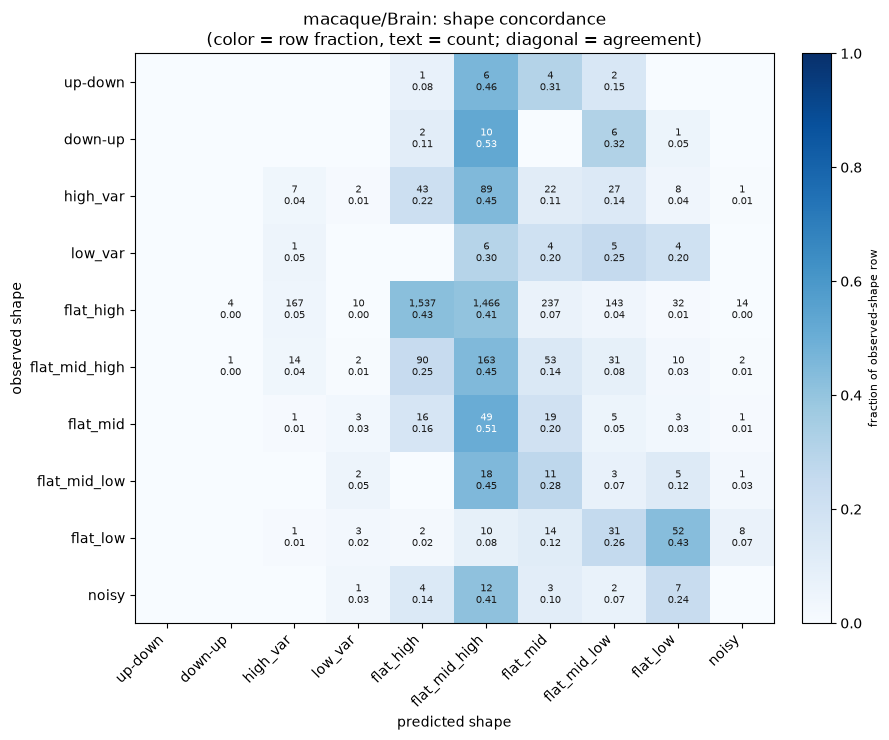

In [10]:
def plot_shape_concordance(dsub, species, tissue, out_directory, save=True):
    """Section 3 diagnostic: observed-vs-predicted shape concordance matrix for one
    species/tissue's prediction-cluster table."""
    shapes = [s for s in SHAPE_ORDER if s in set(dsub["obs_shape"]) | set(dsub["pred_shape"])]
    ct = pd.crosstab(dsub["obs_shape"], dsub["pred_shape"]).reindex(index=shapes, columns=shapes, fill_value=0)
    frac_rows = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0)

    fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(shapes) + 3), max(5, 0.55 * len(shapes) + 2)))
    im = ax.imshow(frac_rows.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(shapes))); ax.set_xticklabels(shapes, rotation=45, ha="right")
    ax.set_yticks(range(len(shapes))); ax.set_yticklabels(shapes)
    ax.set_xlabel("predicted shape"); ax.set_ylabel("observed shape")
    ax.set_title(f"{species}/{tissue}: shape concordance\n(color = row fraction, text = count; diagonal = agreement)")
    for i in range(len(shapes)):
        for j in range(len(shapes)):
            f = frac_rows.iloc[i, j]
            if ct.iloc[i, j]:
                ax.text(j, i, f"{int(ct.iloc[i, j]):,}\n{f:.2f}" if np.isfinite(f) else f"{int(ct.iloc[i, j]):,}",
                        ha="center", va="center", fontsize=7,
                        color="white" if (np.isfinite(f) and f > 0.5) else "#1a1a1a")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("fraction of observed-shape row", fontsize=8)
    plt.tight_layout()
    if save:
        fig.savefig(os.path.join(out_directory, f"{prefix(species, tissue)}_shape_concordance.png"),
                    dpi=200, bbox_inches="tight")
    plt.show()

plot_shape_concordance(df, SPECIES, TISSUE, OUT_DIR)

## 4 — Per-shape agreement and effect of coverage / centroid distance

Single walk-through example (`SPECIES`/`TISSUE`). **Section 8** repeats this diagnostic for every
species × tissue combination.

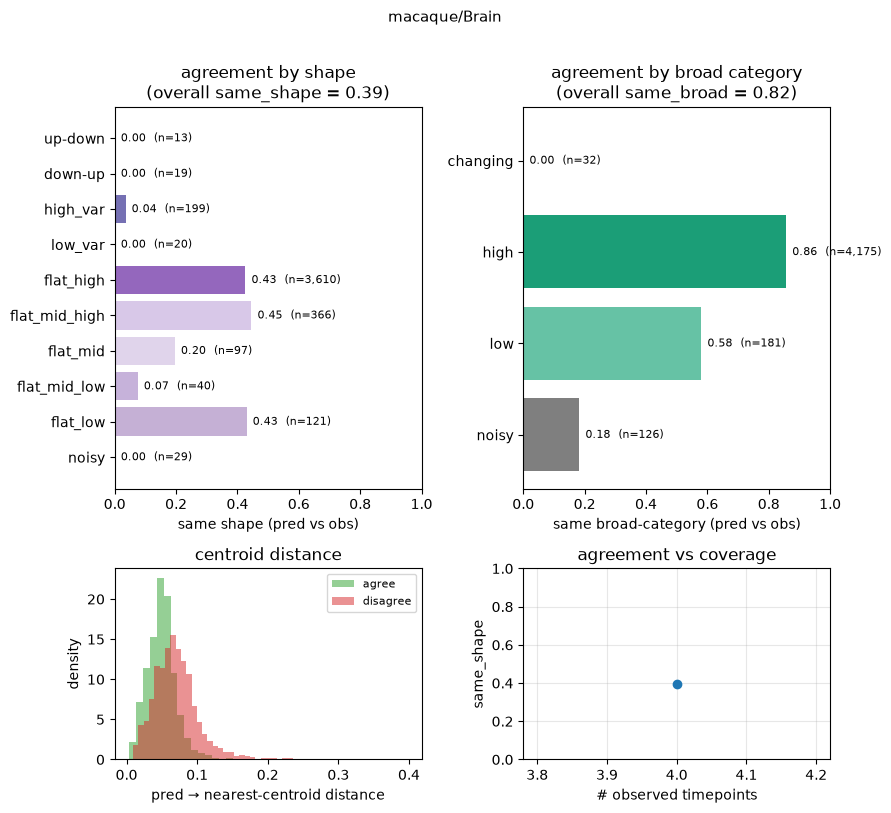

In [11]:
# broad categories: up / down / changing / high / low / flat_high / flat_low / noisy
BROAD = {**{s: "up"   for s in ["up_early", "up_late", "up_mid"]},
         **{s: "down" for s in ["down_early", "down_late", "down_mid"]},
         **{s: "changing" for s in ['up-down', 'down-up']},
         **{s: "high" for s in ["high_up", "high_down", "high_var", 'flat_high', 'flat_mid_high']},
         **{s: "low" for s in ["low_up", "low_down", "low_var", 'flat_low', 'flat_mid_low']},
         **{s: "noisy" for s in ['noisy', 'flat_mid']}
         }
BROAD_ORDER  = ["up", "down", "changing", "high", "low", "noisy"]
BROAD_COLORS = {
    "up": "#1a7a1a",
    "down": "#a01010",
    "changing": "#ff7f0e",
    "high": "#1b9e77",
    "low": "#66c2a5",
    "flat_high": "#9467bd",
    "flat_low": "#c5b0d5",
    "noisy": "#7f7f7f"}
def broad(s): return BROAD.get(s, "noisy")

def add_broad_columns(dsub):
    dsub = dsub.copy()
    dsub["obs_broad"]  = dsub["obs_shape"].map(broad)
    dsub["pred_broad"] = dsub["pred_shape"].map(broad)
    dsub["same_broad"] = dsub["obs_broad"] == dsub["pred_broad"]
    return dsub

def plot_agreement_breakdown(dsub, species, tissue, out_directory, save=True):
    """Section 4 diagnostic: per-shape / per-broad-category agreement, centroid-distance
    separation, and agreement vs. coverage — for one species/tissue's prediction-cluster
    table. Adds obs_broad/pred_broad/same_broad if missing."""
    if "obs_broad" not in dsub.columns:
        dsub = add_broad_columns(dsub)

    fig, axes = plt.subplots(2, 2, figsize=(9, 8), height_ratios=[2, 1], sharex=False, sharey=False)

    # (a) per observed category agreement
    by_shape = (dsub.groupby("obs_shape")["same_shape"].agg(["mean", "size"])
                  .reindex(SHAPE_ORDER).dropna())
    ax = axes[0, 0]
    ax.barh(range(len(by_shape)), by_shape["mean"],
            color=[SHAPE_COLORS[s] for s in by_shape.index])
    ax.set_yticks(range(len(by_shape))); ax.set_yticklabels(by_shape.index)
    ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel("same shape (pred vs obs)")
    ax.set_title(f"agreement by shape\n(overall same_shape = {dsub['same_shape'].mean():.2f})")
    for i, (m, n) in enumerate(zip(by_shape["mean"], by_shape["size"])):
        ax.text(min(m + 0.02, 0.98), i, f"{m:.2f}  (n={int(n):,})", va="center", fontsize=8)

    # (b) per observed broad category agreement
    by_broad = (dsub.groupby("obs_broad")["same_broad"].agg(["mean", "size"])
                  .reindex(BROAD_ORDER).dropna())
    ax = axes[0, 1]
    ax.barh(range(len(by_broad)), by_broad["mean"],
            color=[BROAD_COLORS[b] for b in by_broad.index])
    ax.set_yticks(range(len(by_broad))); ax.set_yticklabels(by_broad.index)
    ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel("same broad-category (pred vs obs)")
    ax.set_title(f"agreement by broad category\n(overall same_broad = {dsub['same_broad'].mean():.2f})")
    for i, (m, n) in enumerate(zip(by_broad["mean"], by_broad["size"])):
        ax.text(min(m + 0.02, 0.98), i, f"{m:.2f}  (n={int(n):,})", va="center", fontsize=8)

    # (c) predicted-centroid distance, agree vs disagree
    ax = axes[1, 0]
    for lab, sub, c in [("agree", dsub[dsub["same_shape"]], "#2ca02c"),
                        ("disagree", dsub[~dsub["same_shape"]], "#d62728")]:
        ax.hist(sub["pred_centroid_dist"], bins=40, alpha=0.5, label=lab, color=c, density=True)
    ax.set_xlabel("pred → nearest-centroid distance"); ax.set_ylabel("density")
    ax.set_title("centroid distance"); ax.legend(fontsize=8)

    # (d) agreement vs observed timepoints
    ax = axes[1, 1]
    g = dsub.groupby("n_obs")["same_shape"].mean()
    ax.plot(g.index, g.values, "o-", color="#1f77b4")
    ax.set_xlabel("# observed timepoints"); ax.set_ylabel("same_shape"); ax.set_ylim(0, 1)
    ax.set_title("agreement vs coverage"); ax.grid(alpha=0.3)

    fig.suptitle(f"{species}/{tissue}", fontsize=11, y=1.01)
    plt.tight_layout()
    if save:
        fig.savefig(os.path.join(out_directory, f"{prefix(species, tissue)}_agreement_breakdown.png"),
                    dpi=200, bbox_inches="tight")
    plt.show()
    return dsub

df = plot_agreement_breakdown(df, SPECIES, TISSUE, OUT_DIR)

In [12]:
# Raw SSE_true / SSE_pred trajectory lookup for the walk-through SPECIES/TISSUE, used by the
# example plots below. Cached lazily (on first call) so it works regardless of which order
# downstream cells get run in, without eagerly reloading the (large) predicted-usage parquet.
_traj_cache = {}

def _traj(chrom, pos):
    key = (SPECIES, TISSUE)
    if key not in _traj_cache:
        p = pd.read_parquet(preds_parquet_path(SPECIES),
                            columns=["Chromosome", "Position", "Tissue", "Timepoint",
                                     "SSE_true", "SSE_pred"])
        p = p[p["Tissue"] == TISSUE].copy()
        p["Chromosome"] = p["Chromosome"].astype(str)
        _traj_cache[key] = p
    p = _traj_cache[key]
    s = p[(p["Chromosome"] == str(chrom)) & (p["Position"] == int(pos))].sort_values("Timepoint")
    return s["Timepoint"].to_numpy(), s["SSE_true"].to_numpy(), s["SSE_pred"].to_numpy()

## 5 — Examples by shape category: correct vs incorrect predictions

For each of the 14 fine shape labels (`SHAPE_ORDER`), a few observed sites classified into that
shape, split into **correct** (`pred_shape == obs_shape`) and **incorrect** predictions. True/pred
line colors reuse `SHAPE_COLORS` (keyed by each trajectory's own obs/pred label, so matching colors
= correct at a glance); the axis border reuses the agree = green / disagree = red code from
Section 4.

In [13]:
def show_examples_by_category(data, cat_col, obs_col, pred_col, same_col, colors, order,
                              species, tissue, n=4, seed=0):
    """One figure per category in `order` (skipping empty ones): top row = correctly
    predicted examples (``data[pred_col] == data[obs_col]``), bottom row = incorrect.
    Line colors reuse `colors` (``SHAPE_COLORS`` / ``BROAD_COLORS``), keyed per-row by
    that trajectory's own obs/pred label; axis borders reuse the agree=green /
    disagree=red code from Section 4."""
    for cat in order:
        sub = data[data[cat_col] == cat]
        if sub.empty:
            continue
        correct   = sub[sub[same_col]].sample(frac=1, random_state=seed)
        incorrect = sub[~sub[same_col]].sample(frac=1, random_state=seed)
        ncol = max(1, min(n, max(len(correct), len(incorrect))))
        fig, axes = plt.subplots(2, ncol, figsize=(ncol * 3.0, 5.2), squeeze=False)
        for row, (label, group) in enumerate(
            [("correct", correct), ("incorrect", incorrect)]
        ):
            for j in range(ncol):
                ax = axes[row, j]
                if j >= len(group):
                    ax.set_visible(False); continue
                r = group.iloc[j]
                t, yt, yp = _traj(r["Chromosome"], r["Position"])
                oc = colors.get(r[obs_col], "#333333")
                pc = colors.get(r[pred_col], "#333333")
                ax.plot(t, yt, "-o", ms=3, color=oc, lw=2, label="true")
                ax.plot(t, yp, "--x", ms=4, color=pc, lw=2, label="pred")
                ax.set_ylim(-0.05, 1.05); ax.set_xlim(0.5, 15.5)
                ax.set_title(f"{r['Chromosome']}:{r['Position']}\n"
                             f"obs={r[obs_col]} / pred={r[pred_col]}", fontsize=7)
                ax.grid(alpha=0.3)
            axes[row, 0].set_ylabel(f"{label}\nSSE", fontsize=8)
        if len(correct):
            axes[0, 0].legend(fontsize=6, loc="best")
        badge = colors.get(cat, "#7f7f7f")
        fig.suptitle(f"{species}/{tissue}  |  {cat_col}={cat}  "
                    f"(n={len(sub):,}, correct={len(correct):,}, incorrect={len(incorrect):,})",
                    fontsize=10, color=badge, fontweight="bold")
        plt.tight_layout()
        plt.show()

Examples for trajectory shapes:

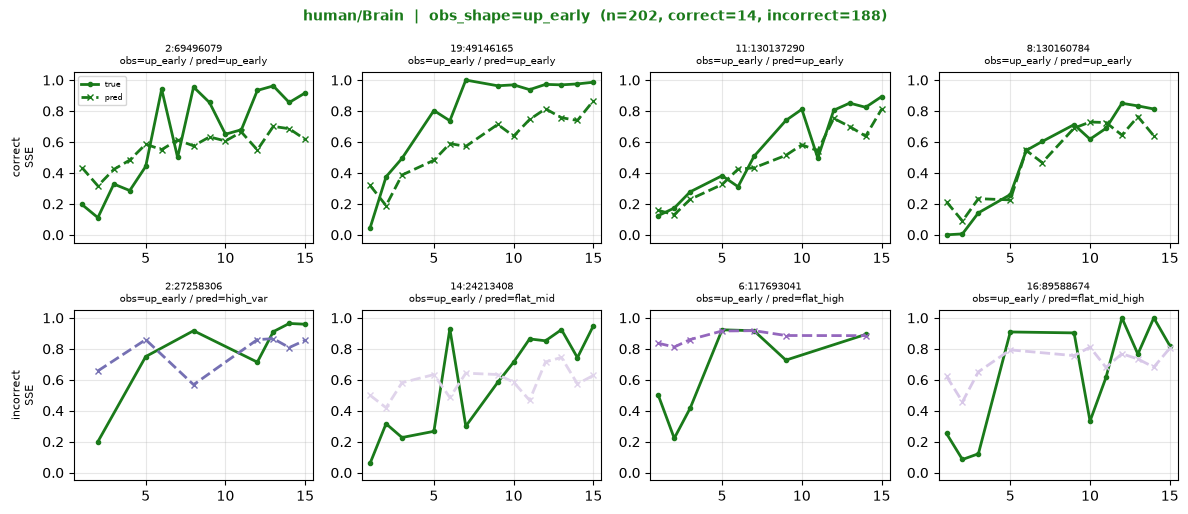

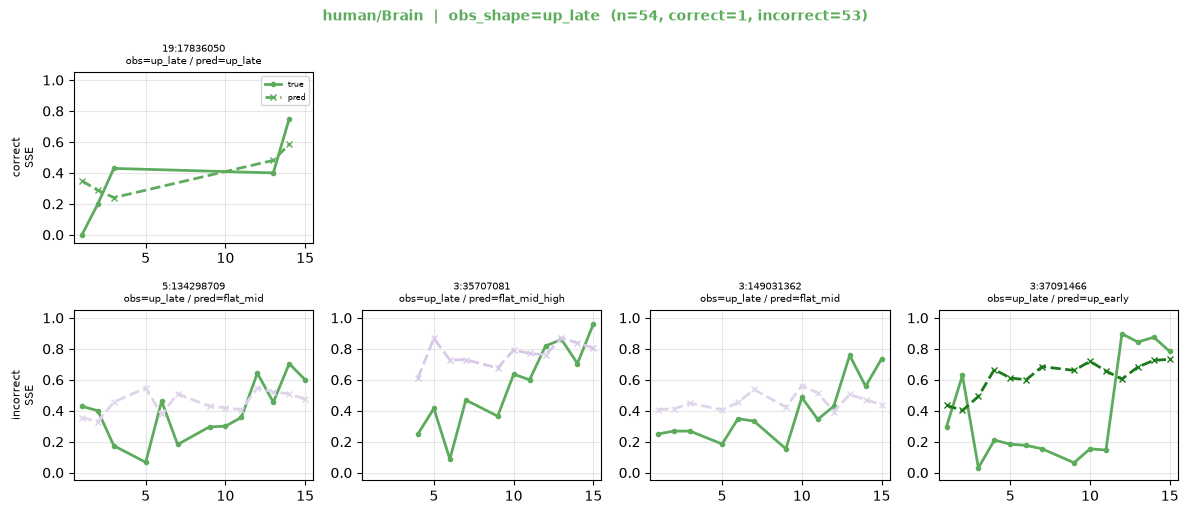

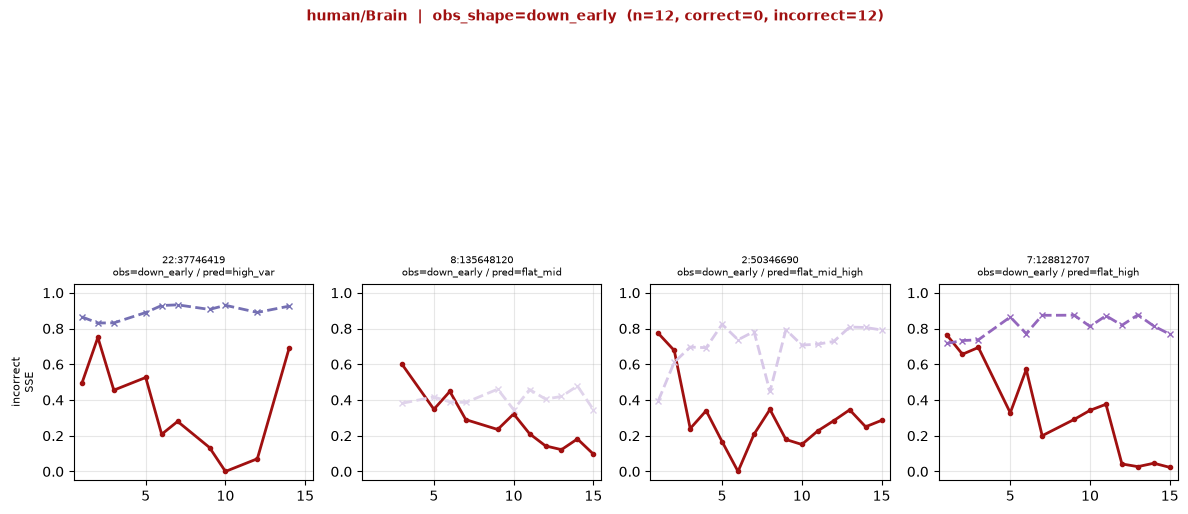

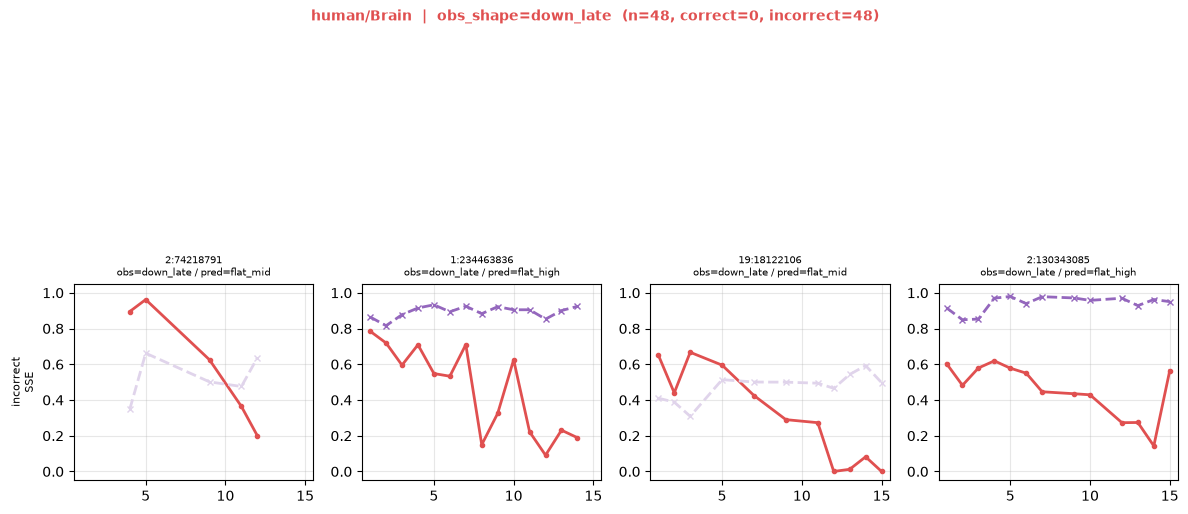

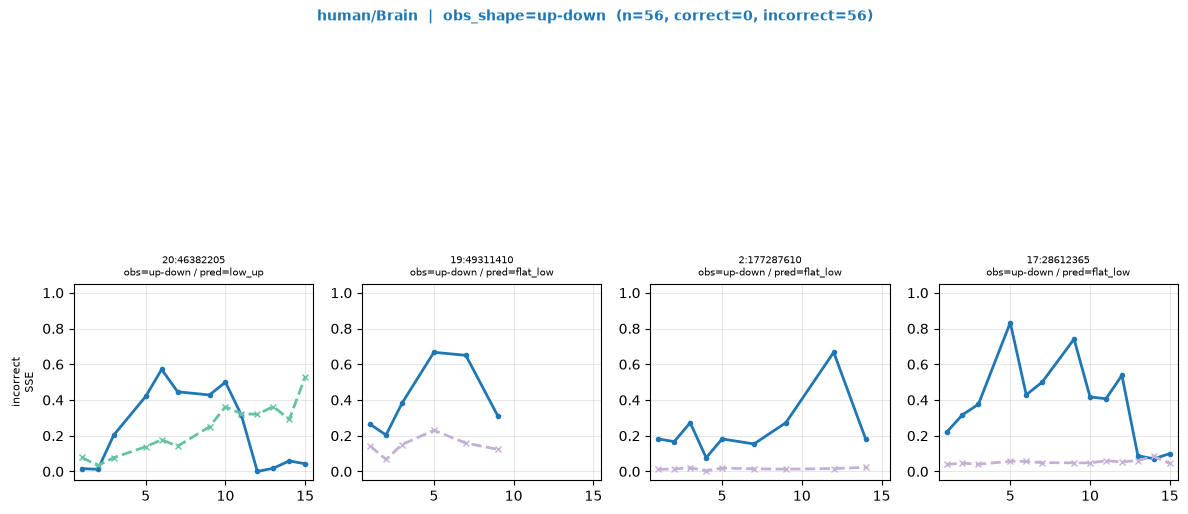

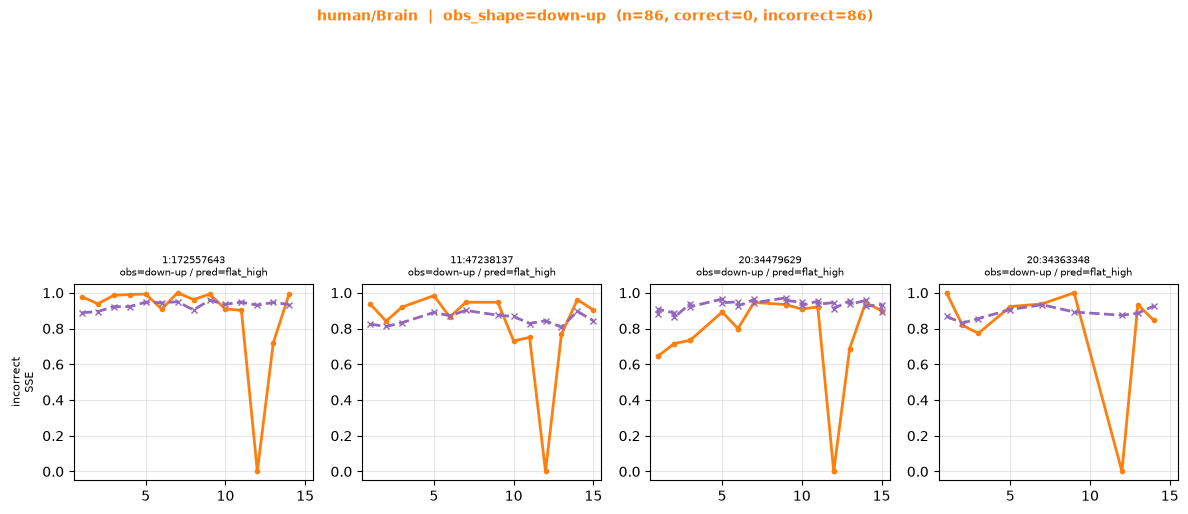

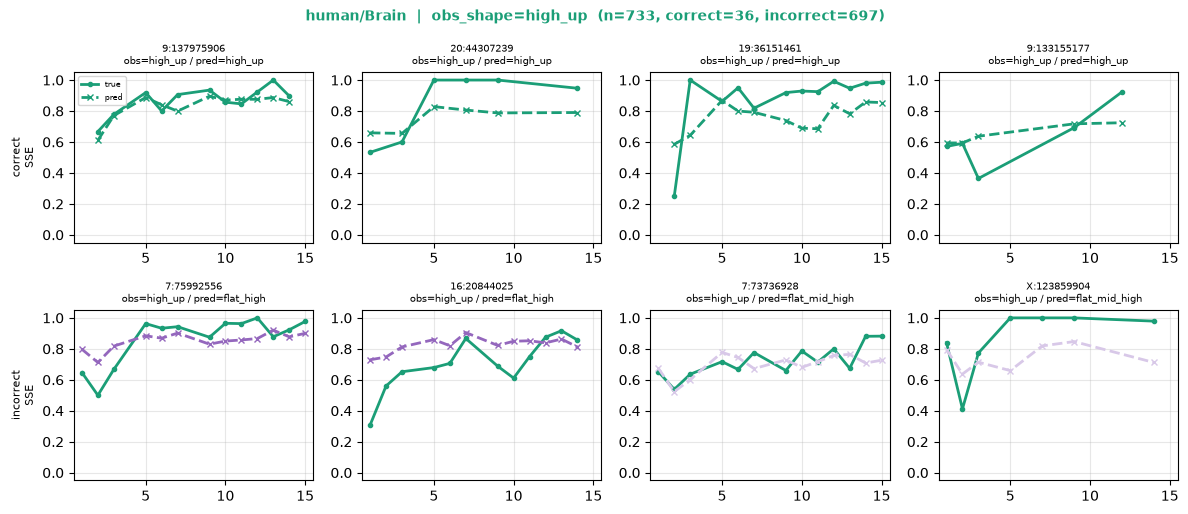

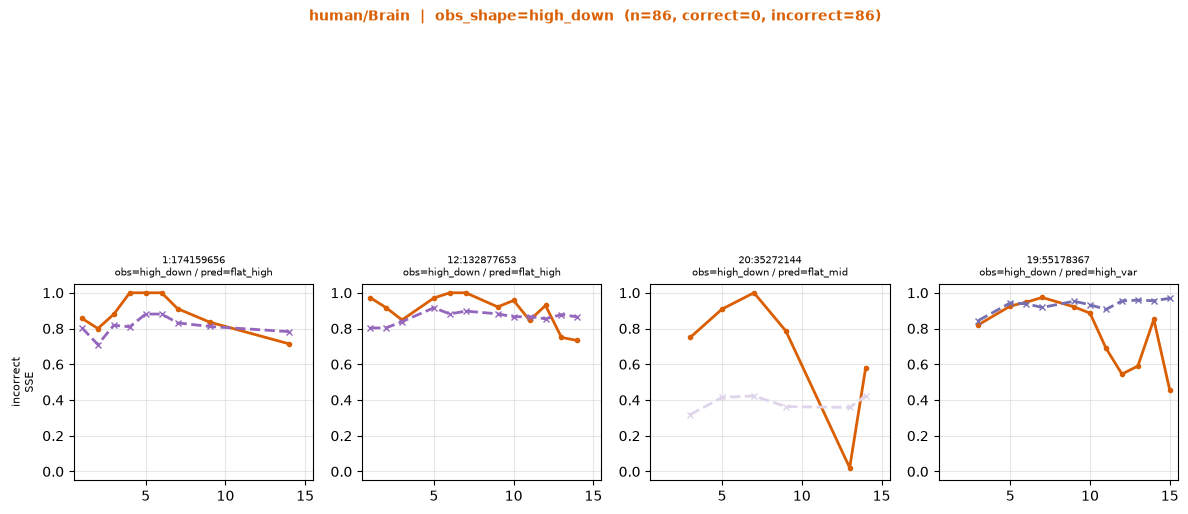

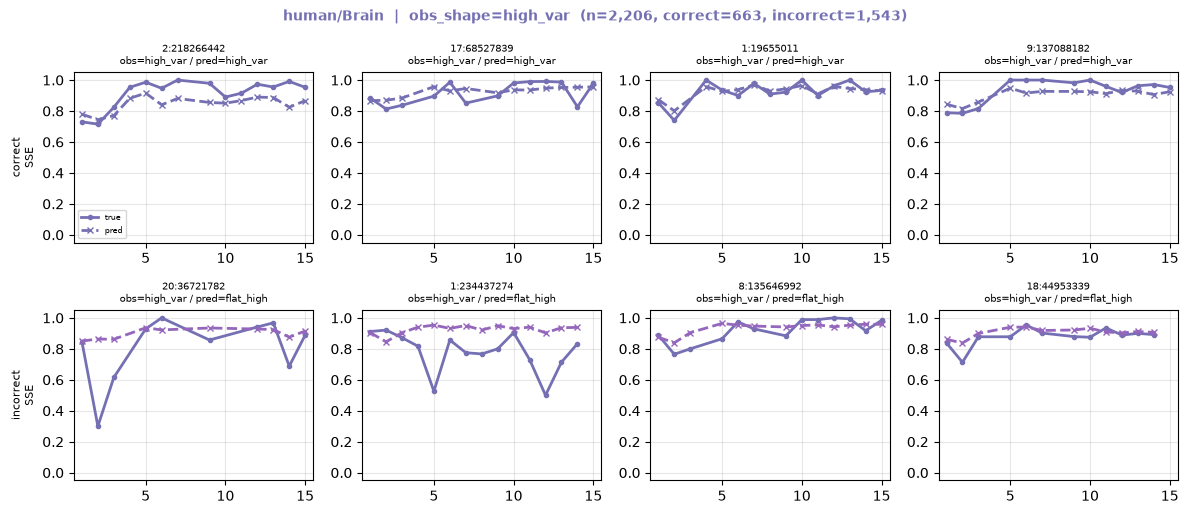

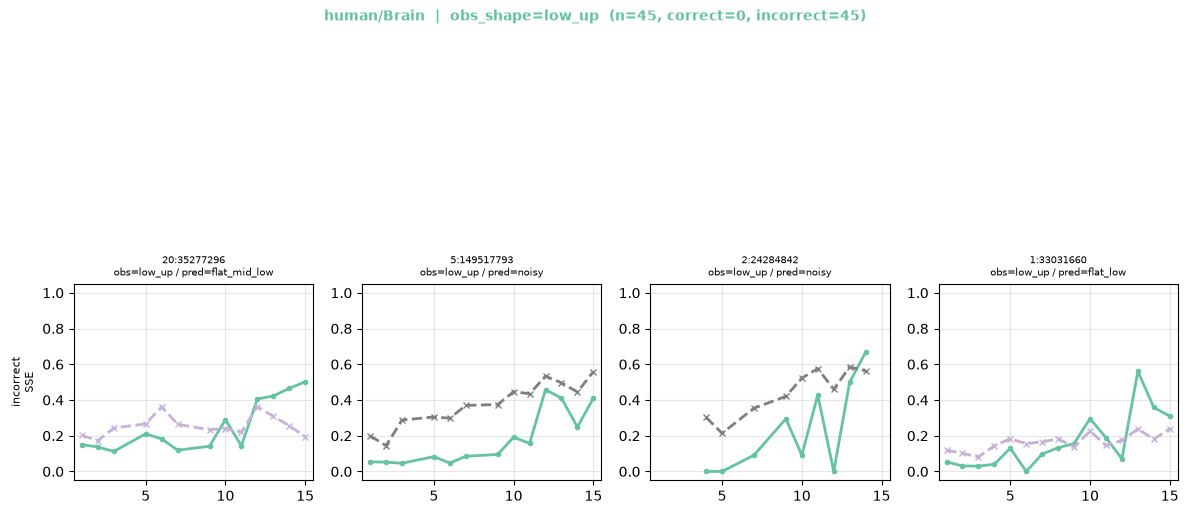

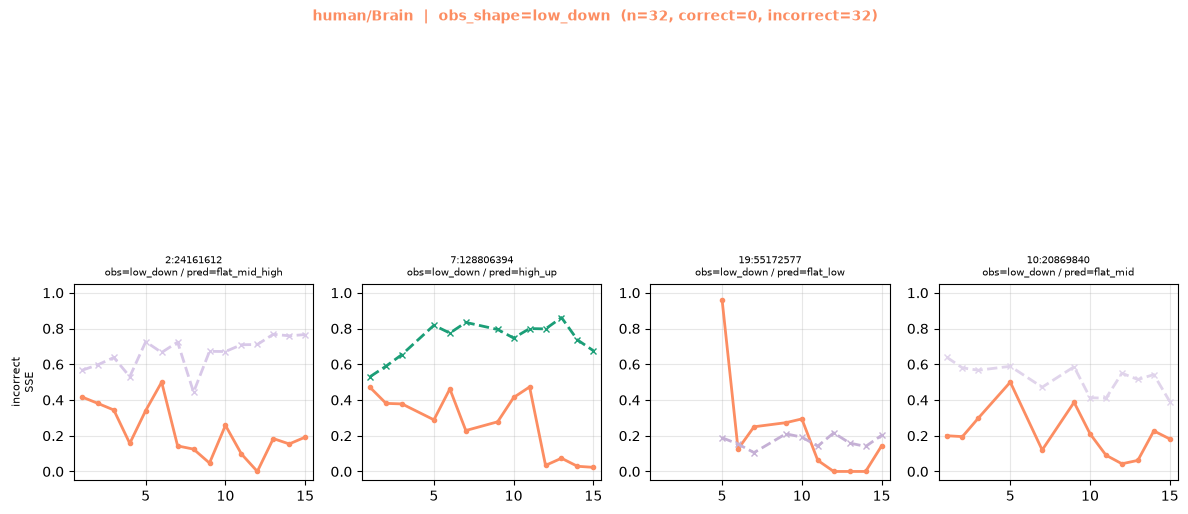

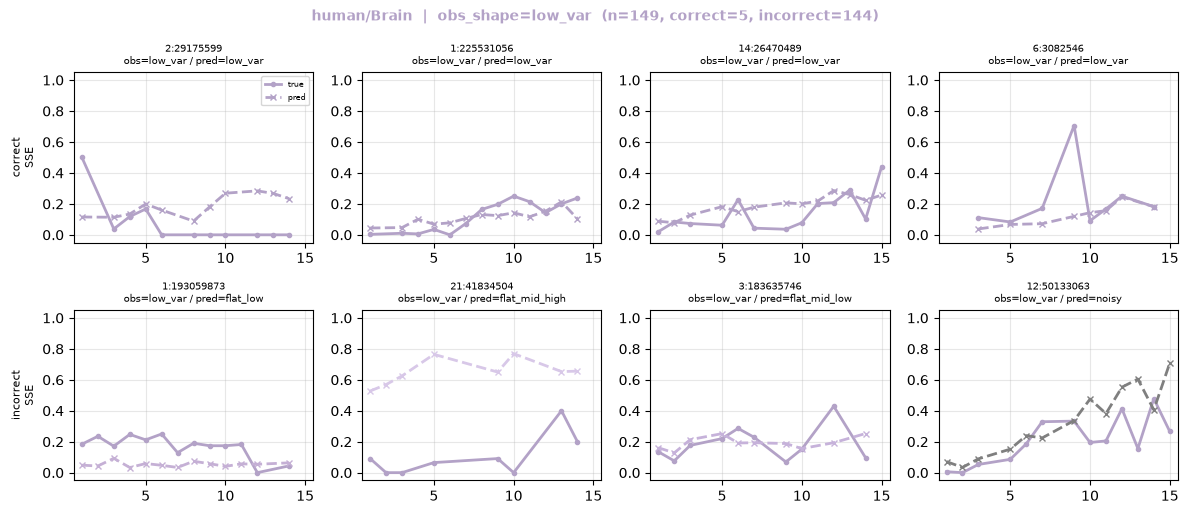

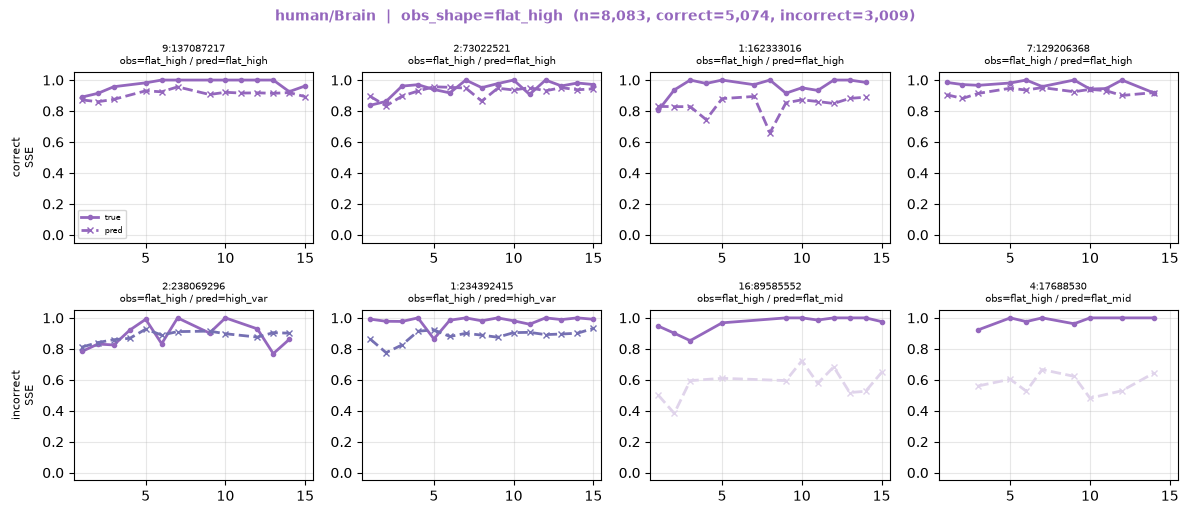

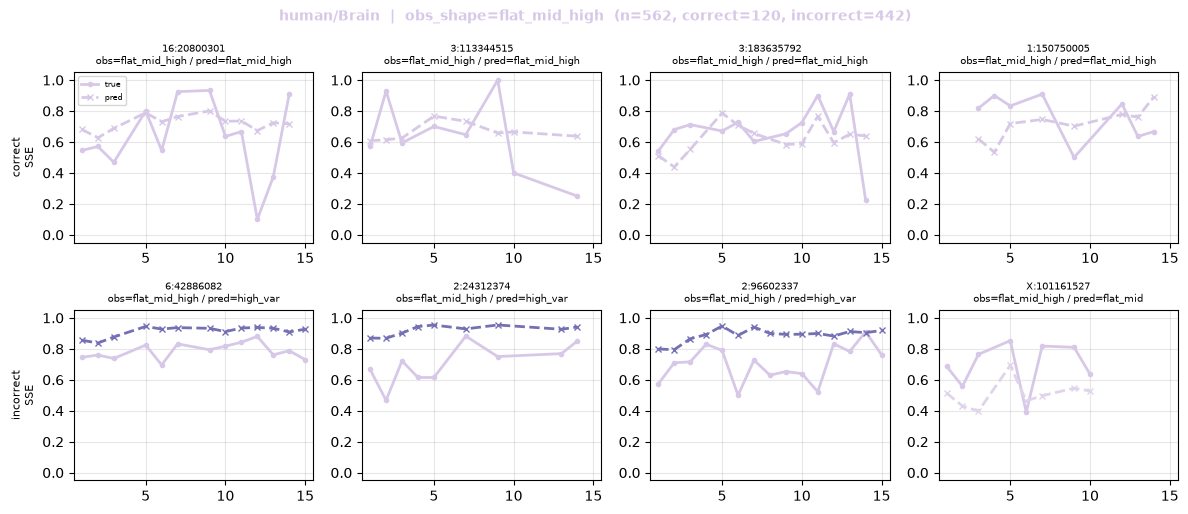

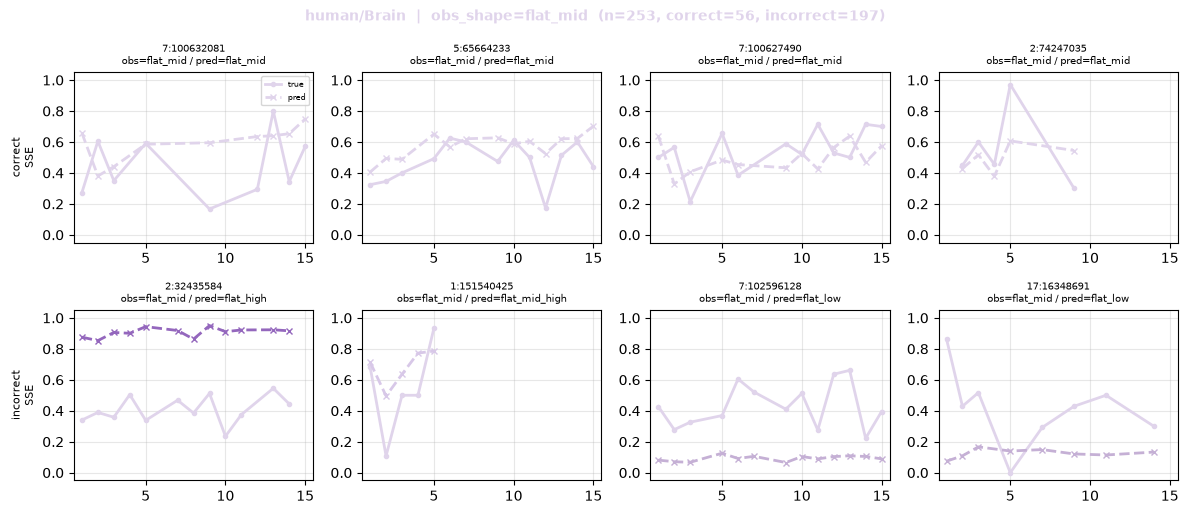

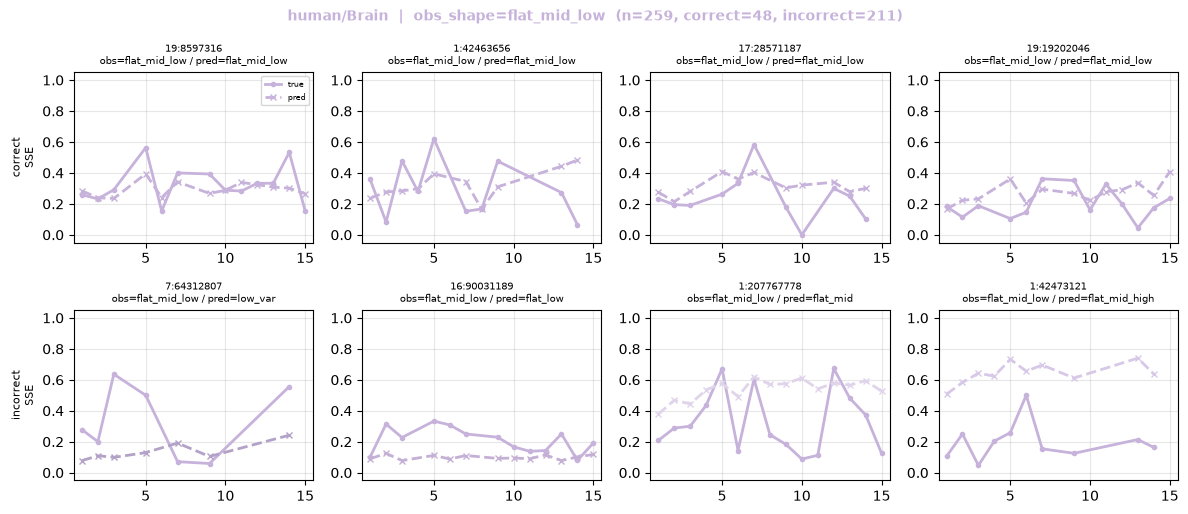

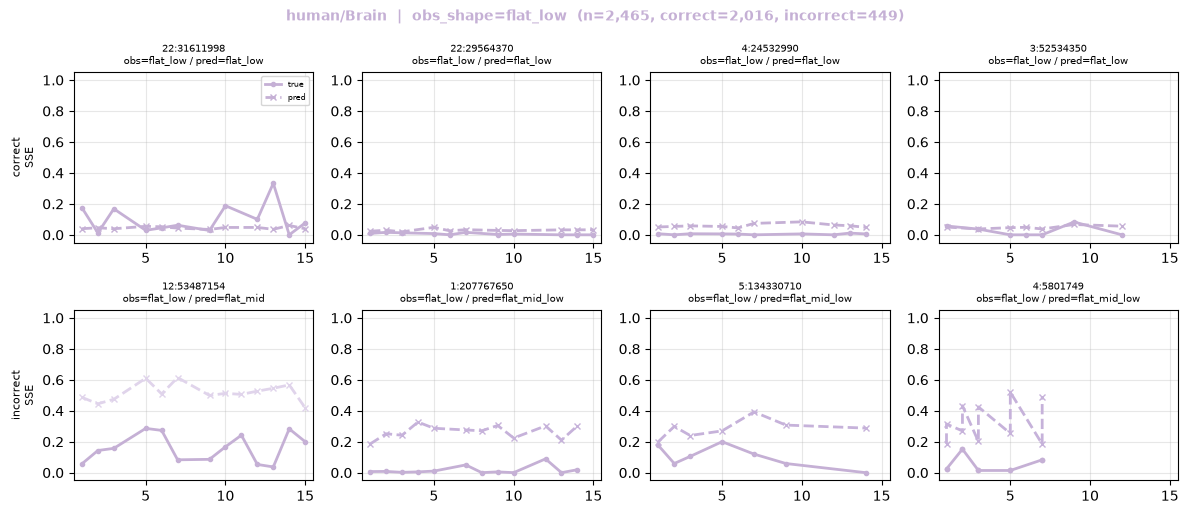

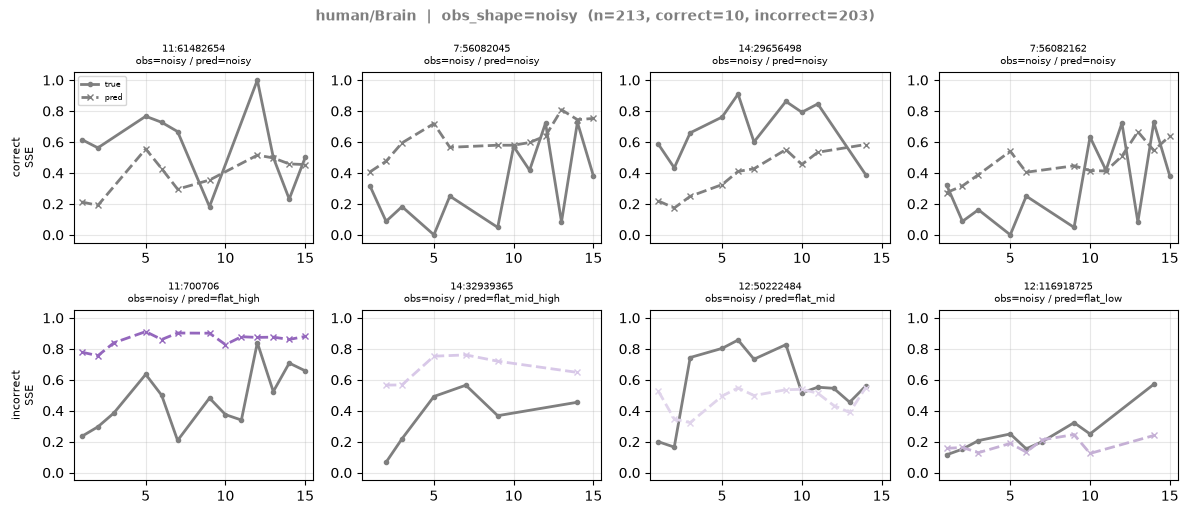

In [10]:
show_examples_by_category(df, "obs_shape", "obs_shape", "pred_shape", "same_shape",
                          SHAPE_COLORS, SHAPE_ORDER, SPECIES, TISSUE, n=4)

Examples for broad trajectory shapes:

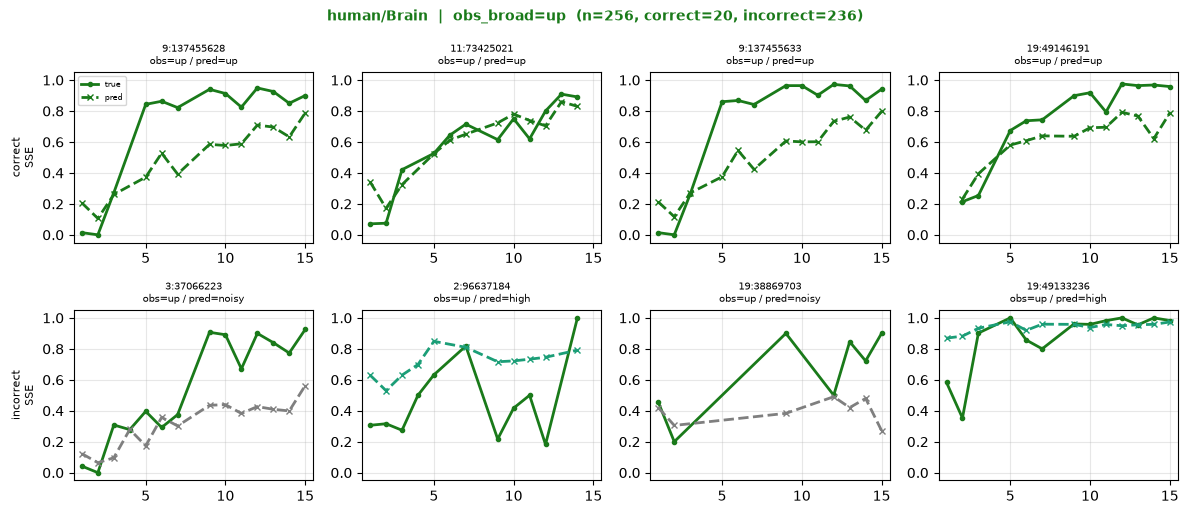

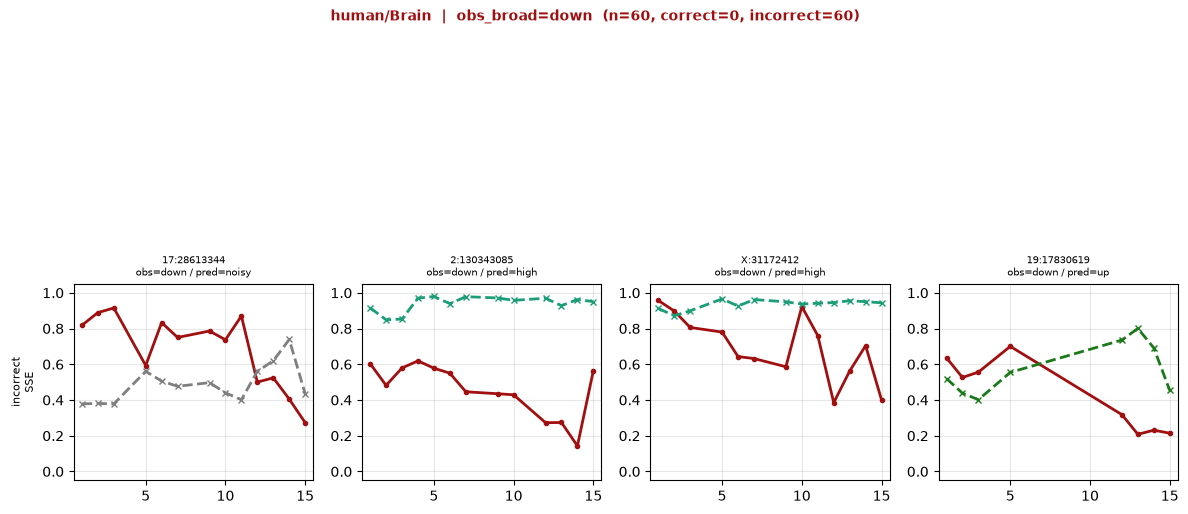

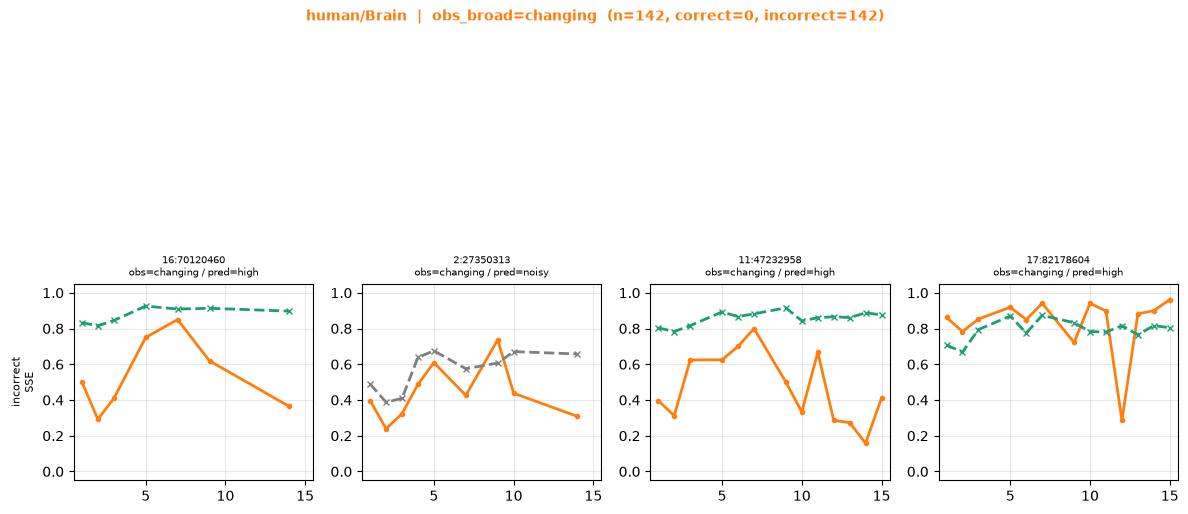

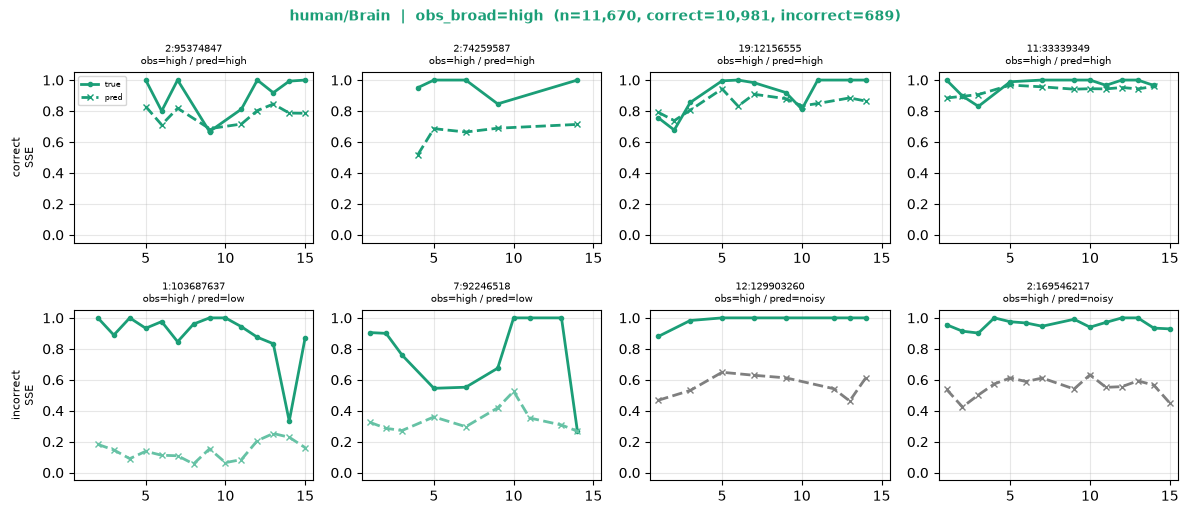

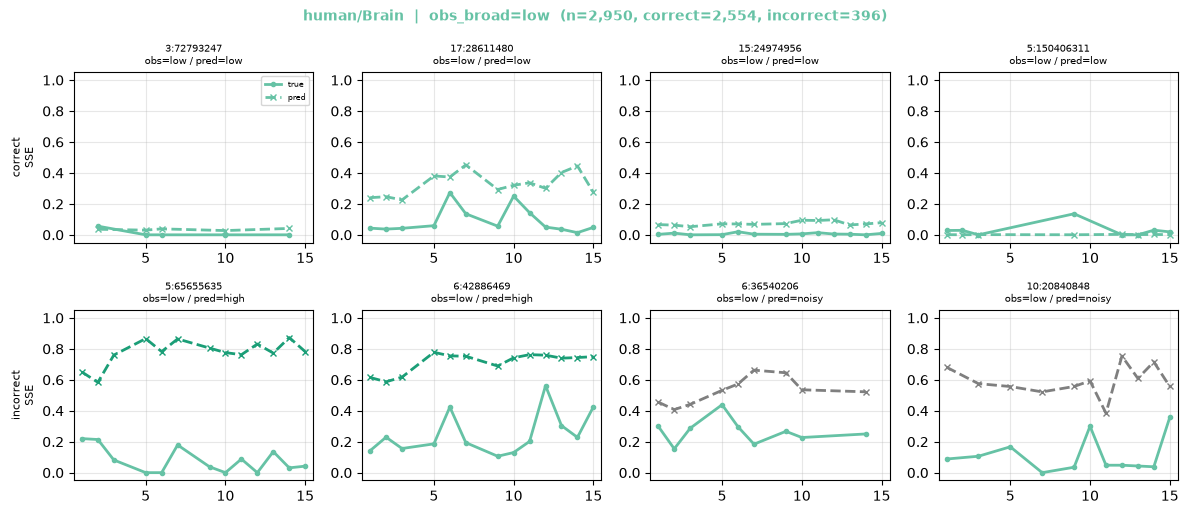

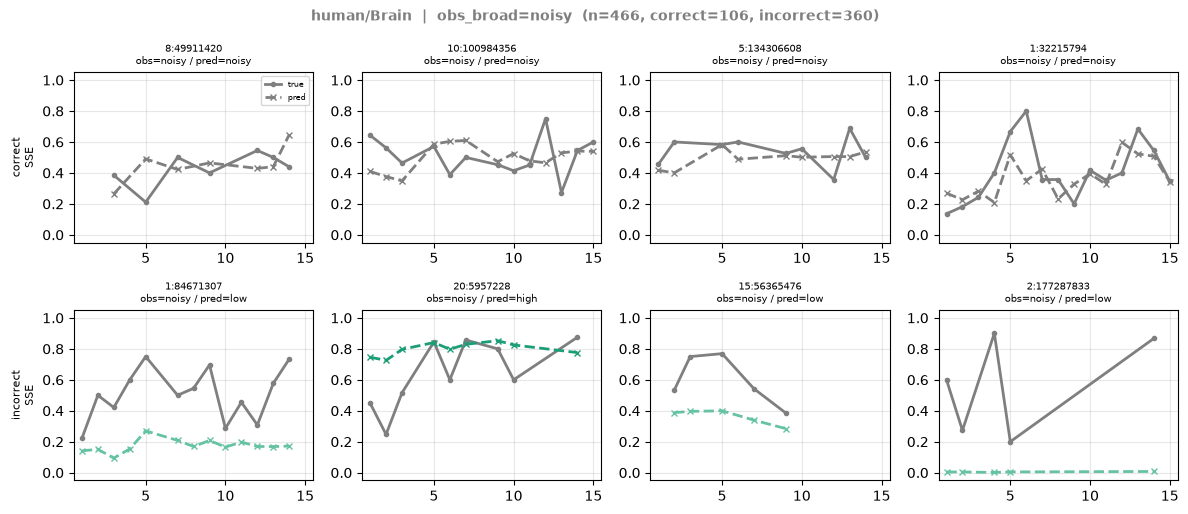

In [11]:
show_examples_by_category(df, "obs_broad", "obs_broad", "pred_broad", "same_broad",
                          BROAD_COLORS, BROAD_ORDER, SPECIES, TISSUE, n=4)

## 8 — Diagnostics for every species × tissue

Re-runs the Section 3 (shape concordance) and Section 4 (per-shape/broad agreement, coverage,
centroid distance) diagnostics for **every** `(species, tissue)` combination in `SPECIES_LIST ×
TISSUE_LIST` that has a prediction-cluster parquet — not just the single walk-through example
above. Figures are saved into each combination's own output directory, using the same
`<prefix>_shape_concordance.png` / `<prefix>_agreement_breakdown.png` naming as the single-example
runs.

4 species x tissue combination(s) with prediction-cluster parquets:
  macaque/Brain
  macaque/Cerebellum
  macaque/Liver
  macaque/Testis

=== macaque/Brain  (4,514 sites) ===


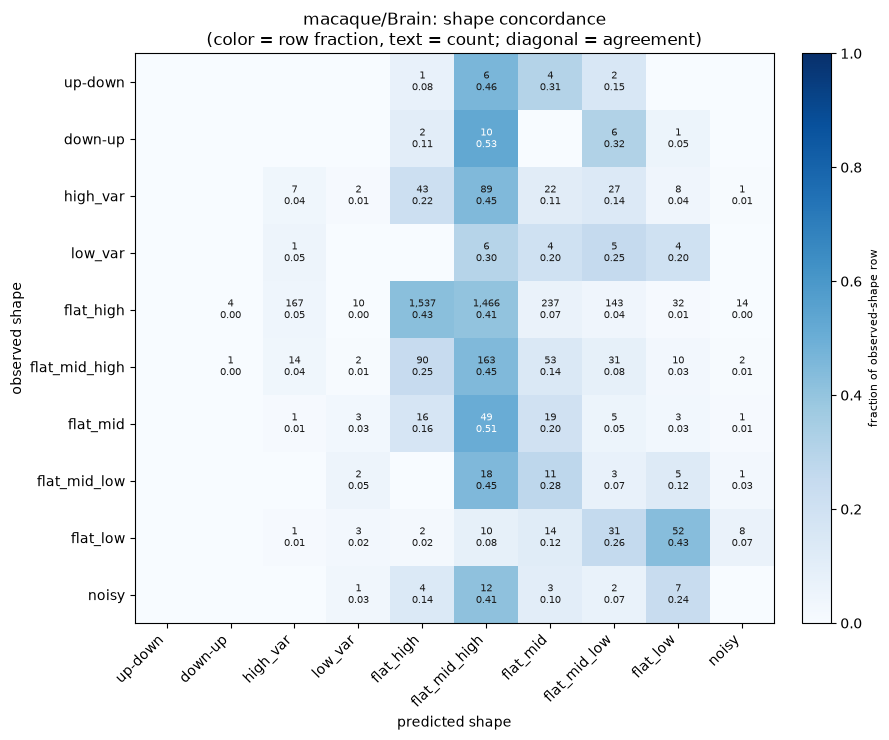

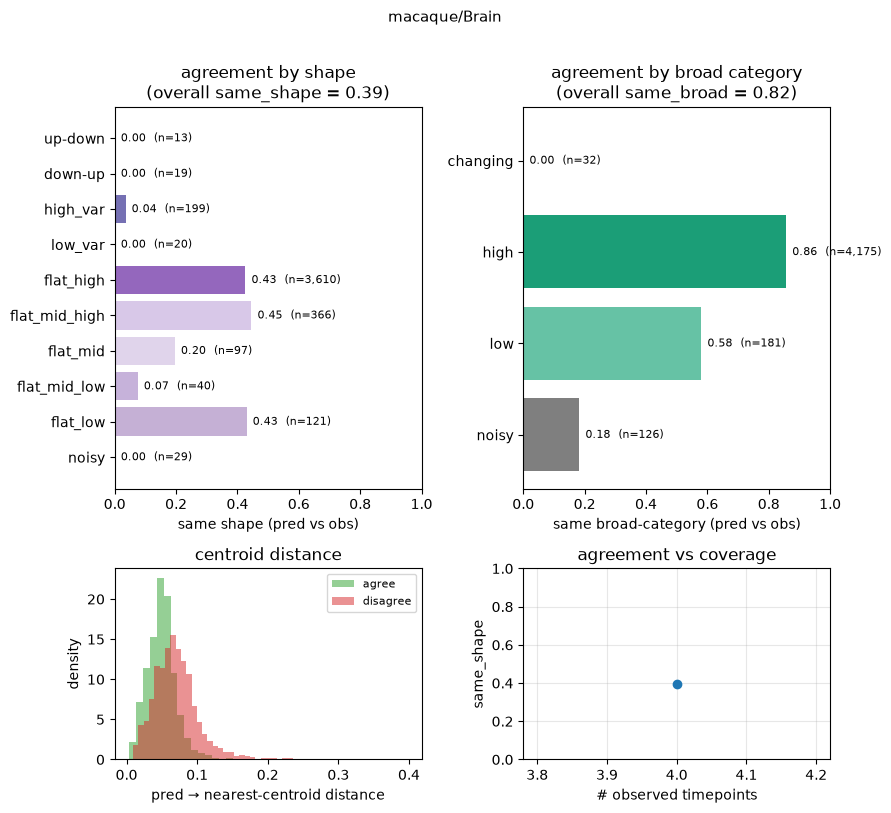


=== macaque/Cerebellum  (3,640 sites) ===


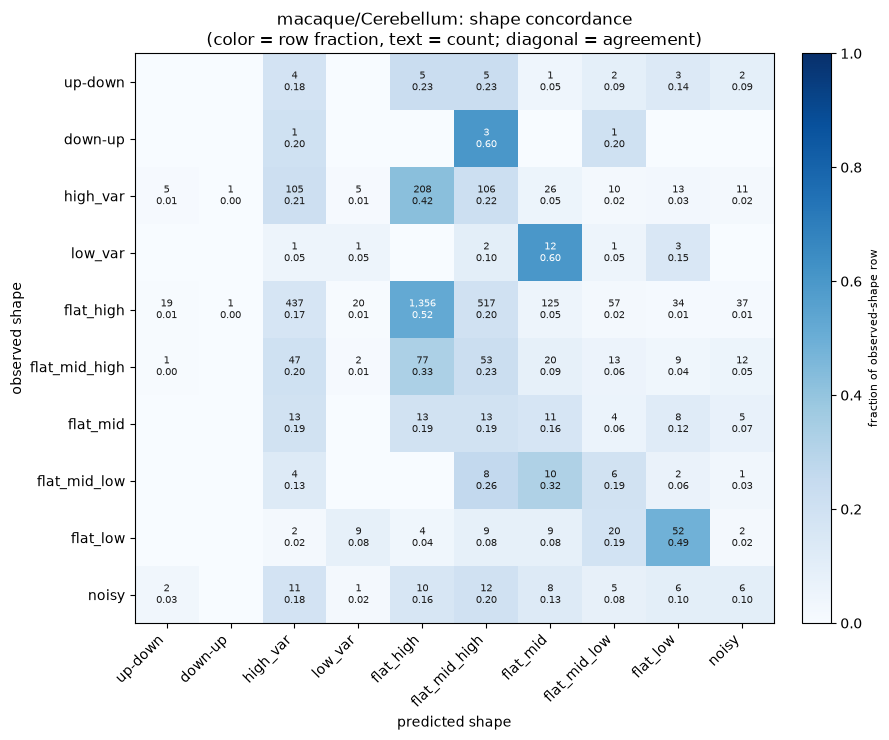

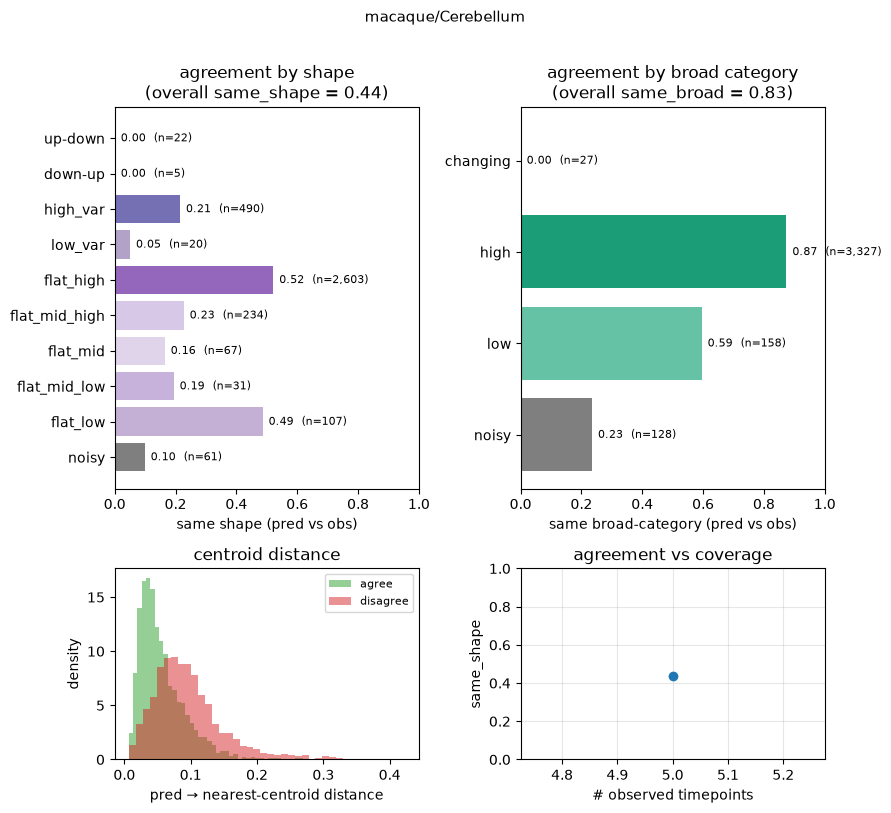


=== macaque/Liver  (3,413 sites) ===


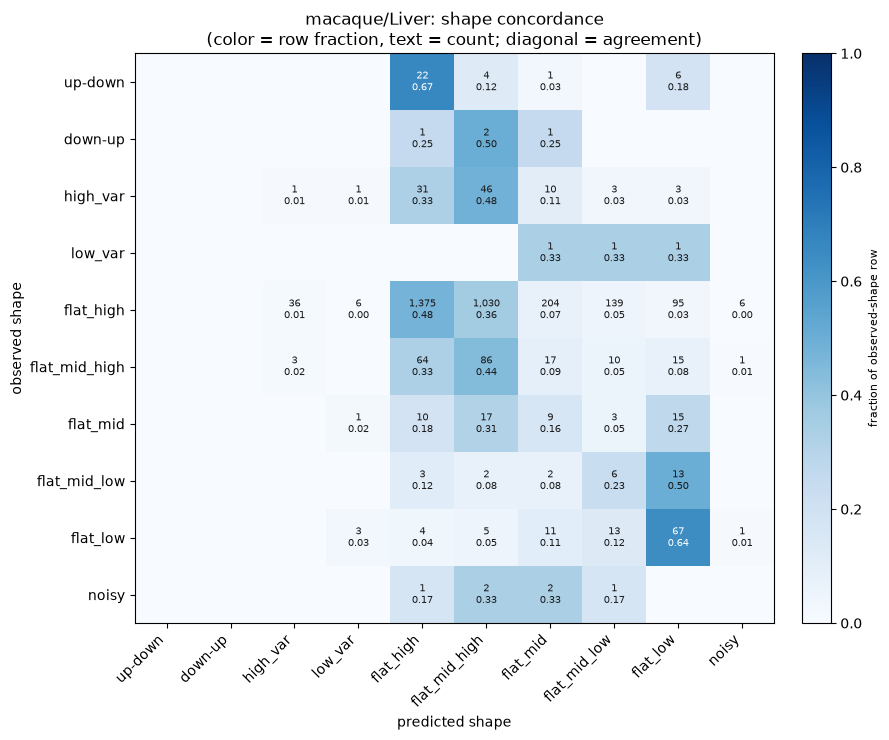

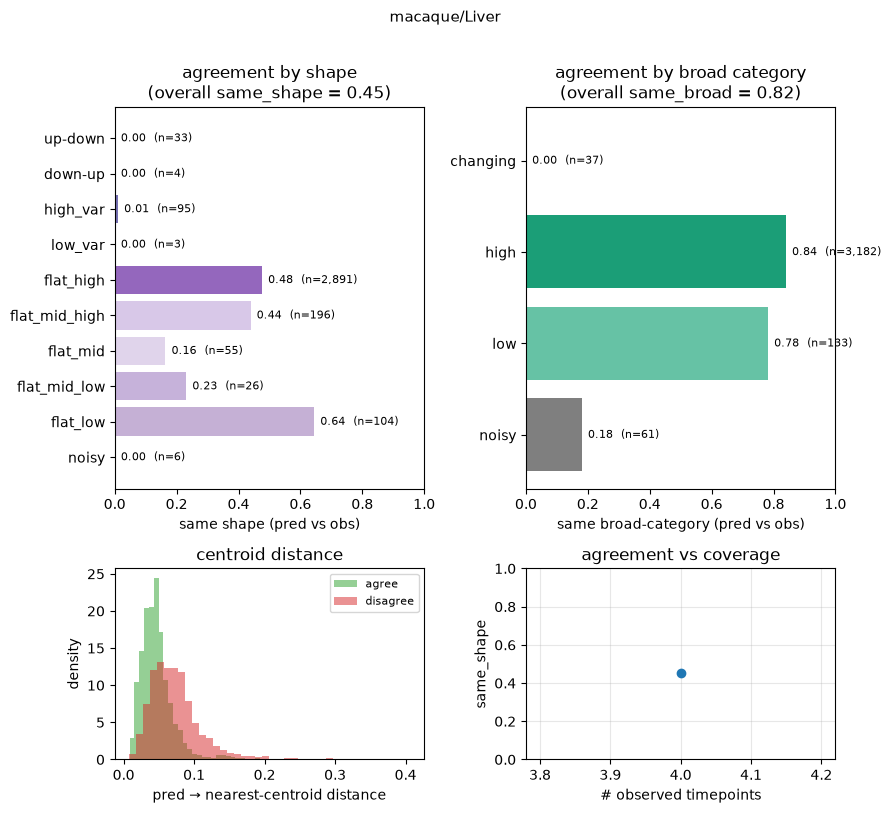


=== macaque/Testis  (4,275 sites) ===


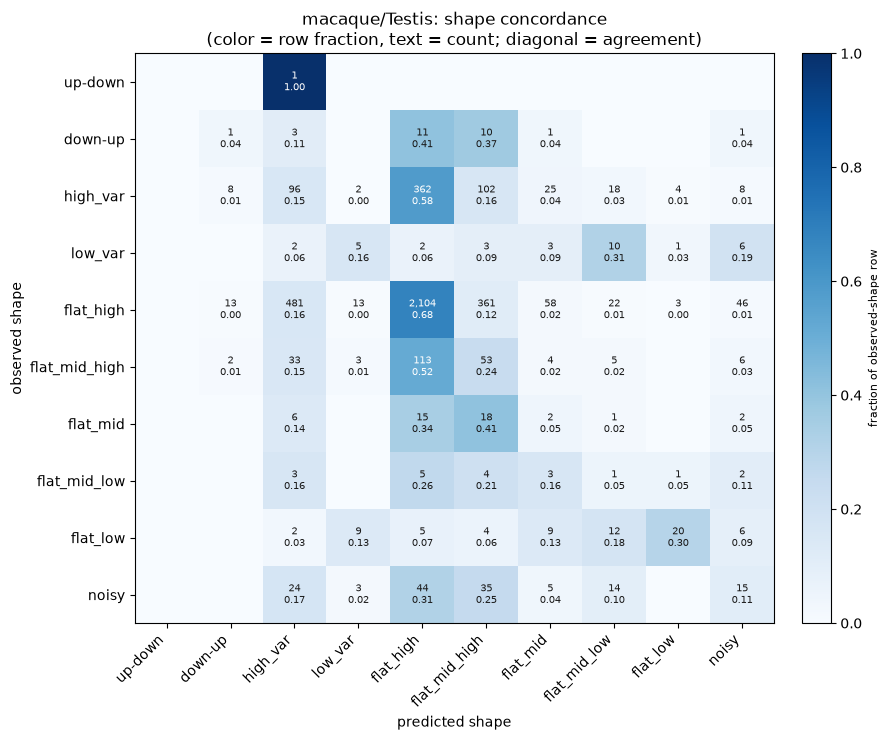

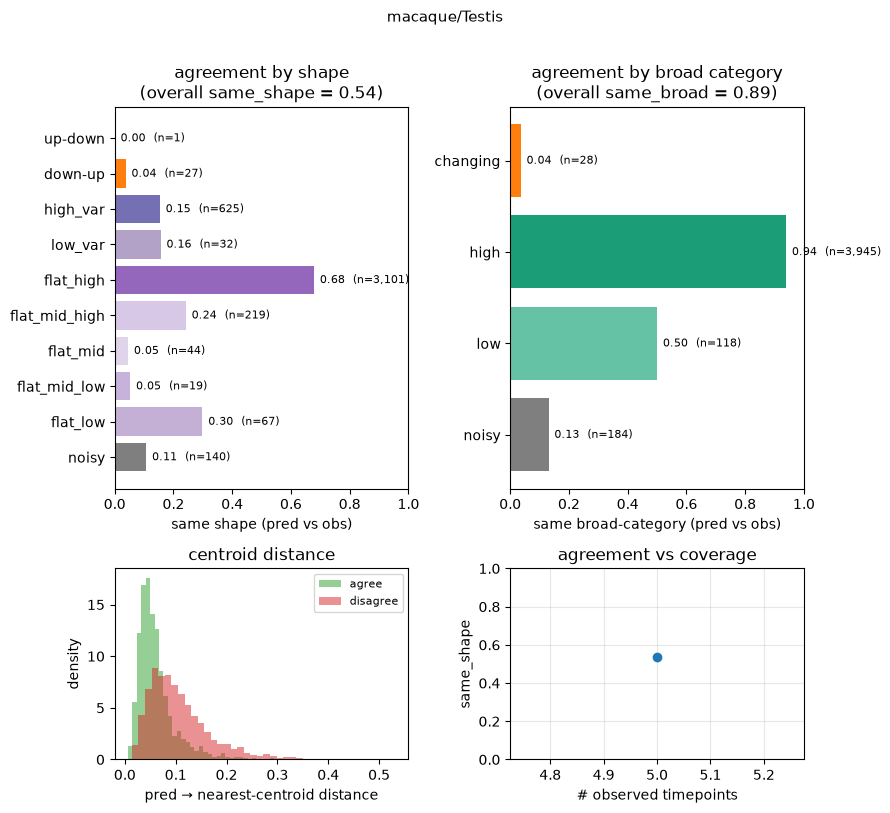

n_sites  shape_pred_vs_obs  broad_pred_vs_obs  \
species tissue                                                      
macaque Brain          4514              0.395              0.821   
        Cerebellum     3640              0.437              0.832   
        Liver          3413              0.452              0.817   
        Testis         4275              0.537              0.886   

                    shape_obs_vs_ref  
species tissue                        
macaque Brain                  0.902  
        Cerebellum             0.833  
        Liver                  0.918  
        Testis                 0.818

In [14]:
combos = [(sp, tis) for sp in SPECIES_LIST for tis in TISSUE_LIST
          if os.path.exists(pred_clusters_path(sp, tis))]
print(f"{len(combos)} species x tissue combination(s) with prediction-cluster parquets:")
for sp, tis in combos:
    print(f"  {sp}/{tis}")

all_diag_rows = []
for sp, tis in combos:
    d = pd.read_parquet(pred_clusters_path(sp, tis))
    d = add_broad_columns(d)
    o = out_dir(sp, tis)
    print(f"\n=== {sp}/{tis}  ({len(d):,} sites) ===")
    plot_shape_concordance(d, sp, tis, o)
    plot_agreement_breakdown(d, sp, tis, o)
    all_diag_rows.append(dict(
        species=sp, tissue=tis, n_sites=len(d),
        shape_pred_vs_obs=round(d["same_shape"].mean(), 3),
        broad_pred_vs_obs=round(d["same_broad"].mean(), 3),
        shape_obs_vs_ref=round((d["obs_shape"] == d["ref_shape"]).mean(), 3),
    ))

all_diag_summary = pd.DataFrame(all_diag_rows).set_index(["species", "tissue"])
display(all_diag_summary)

## 9 — Agreement by shape: species × tissue overview

One heatmap: **x-axis = species × tissue** (grouped by species), **y-axis = shape** (shared,
`SHAPE_ORDER`). Cell color = per-shape `same_shape` agreement, red (disagree) → green (agree) —
reusing the agree/disagree color code from Sections 4-5. Lets you spot at a glance which shapes
are hardest to predict, and whether that's consistent across species/tissues or specific to a
few.

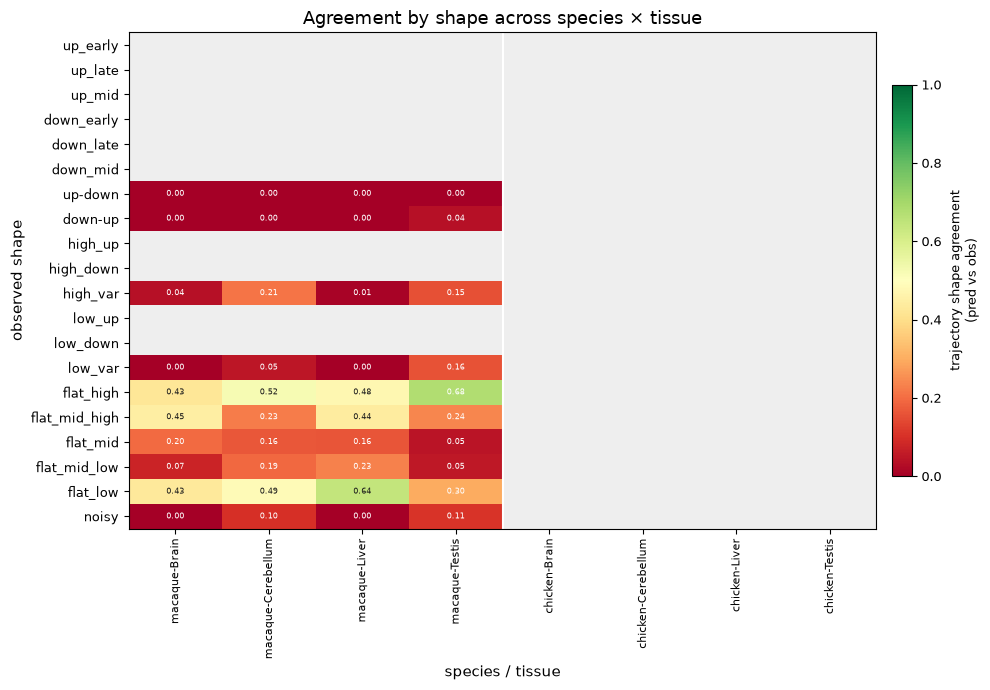

In [15]:
def plot_agreement_by_shape_heatmap(species_list, tissue_list, split=SPLIT, save=True):
    """Section 9: single heatmap, x = species x tissue (grouped by species),
    y = shape (shared, SHAPE_ORDER). Reuses the agree=green / disagree=red code.
    Sized for slides/paper: readable fonts, saved at 600 dpi."""
    combos = [(sp, tis) for sp in species_list for tis in tissue_list]
    mat = np.full((len(SHAPE_ORDER), len(combos)), np.nan)
    labels = []
    for c, (sp, tis) in enumerate(combos):
        labels.append(f"{sp}-{tis}")
        path = pred_clusters_path(sp, tis, split)
        if not os.path.exists(path):
            continue
        d = pd.read_parquet(path, columns=["obs_shape", "same_shape"])
        by_shape = d.groupby("obs_shape")["same_shape"].mean().reindex(SHAPE_ORDER)
        mat[:, c] = by_shape.to_numpy()

    cmap = plt.get_cmap("RdYlGn").copy()
    cmap.set_bad("#eeeeee")
    masked = np.ma.masked_invalid(mat)

    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=1, aspect="auto")

    ax.set_yticks(range(len(SHAPE_ORDER)))
    ax.set_yticklabels(SHAPE_ORDER, fontsize=9)
    ax.set_xticks(range(len(combos)))
    ax.set_xticklabels(labels, fontsize=8, rotation=90, ha="center")

    for r in range(len(SHAPE_ORDER)):
        for c in range(len(combos)):
            v = mat[r, c]
            if np.isfinite(v):
                ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=6,
                        color="white" if (v < 0.35 or v > 0.65) else "#1a1a1a")

    for c in range(len(tissue_list), len(combos), len(tissue_list)):
        ax.axvline(c - 0.5, color="white", lw=1.5)

    ax.set_xlabel("species / tissue", fontsize=11); ax.set_ylabel("observed shape", fontsize=11)
    ax.set_title("Agreement by shape across species × tissue", fontsize=13)
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("trajectory shape agreement\n(pred vs obs)", fontsize=9)
    cbar.ax.tick_params(labelsize=9)
    plt.tight_layout()
    if save:
        fig.savefig(os.path.join(REF_DIR, "agreement_by_shape_species_tissue_heatmap.png"),
                    dpi=600, bbox_inches="tight")
    plt.show()

plot_agreement_by_shape_heatmap(SPECIES_LIST, TISSUE_LIST)

Same view, grouped by the 8 coarser `BROAD_ORDER` categories (Section 4) instead of the 14 fine
shapes.

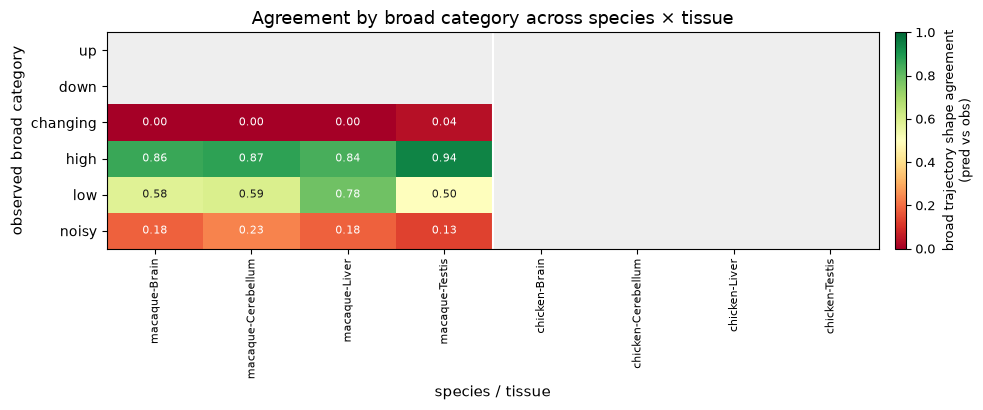

In [16]:
def plot_agreement_by_broad_heatmap(species_list, tissue_list, split=SPLIT, save=True):
    """Section 9 (broad): single heatmap, x = species x tissue (grouped by species),
    y = broad category (shared, BROAD_ORDER). Reuses the agree=green / disagree=red code.
    Sized for slides/paper: readable fonts, saved at 600 dpi."""
    combos = [(sp, tis) for sp in species_list for tis in tissue_list]
    mat = np.full((len(BROAD_ORDER), len(combos)), np.nan)
    labels = []
    for c, (sp, tis) in enumerate(combos):
        labels.append(f"{sp}-{tis}")
        path = pred_clusters_path(sp, tis, split)
        if not os.path.exists(path):
            continue
        d = pd.read_parquet(path, columns=["obs_shape", "pred_shape"])
        obs_broad  = d["obs_shape"].map(broad)
        pred_broad = d["pred_shape"].map(broad)
        by_broad = (obs_broad == pred_broad).groupby(obs_broad).mean().reindex(BROAD_ORDER)
        mat[:, c] = by_broad.to_numpy()

    cmap = plt.get_cmap("RdYlGn").copy()
    cmap.set_bad("#eeeeee")
    masked = np.ma.masked_invalid(mat)

    fig, ax = plt.subplots(figsize=(10, 4.2))
    im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=1, aspect="auto")

    ax.set_yticks(range(len(BROAD_ORDER)))
    ax.set_yticklabels(BROAD_ORDER, fontsize=10)
    ax.set_xticks(range(len(combos)))
    ax.set_xticklabels(labels, fontsize=8, rotation=90, ha="center")

    for r in range(len(BROAD_ORDER)):
        for c in range(len(combos)):
            v = mat[r, c]
            if np.isfinite(v):
                ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=8,
                        color="white" if (v < 0.35 or v > 0.65) else "#1a1a1a")

    for c in range(len(tissue_list), len(combos), len(tissue_list)):
        ax.axvline(c - 0.5, color="white", lw=1.5)

    ax.set_xlabel("species / tissue", fontsize=11); ax.set_ylabel("observed broad category", fontsize=11)
    ax.set_title("Agreement by broad category across species × tissue", fontsize=13)
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("broad trajectory shape agreement\n(pred vs obs)", fontsize=9)
    cbar.ax.tick_params(labelsize=9)
    plt.tight_layout()
    if save:
        fig.savefig(os.path.join(REF_DIR, "agreement_by_broad_species_tissue_heatmap.png"),
                    dpi=600, bbox_inches="tight")
    plt.show()

plot_agreement_by_broad_heatmap(SPECIES_LIST, TISSUE_LIST)